# Coffee futures — research spike

Validates GJR-GARCH(1,1) with Student-t innovations as the forecasting model
for ICE Arabica coffee futures, and calibrates prediction intervals via a
historical backtest.

**What's in here**
1. Load + inspect
2. Prices vs log-returns, ADF stationarity test
3. Drift test (HAC-robust standard errors)
4. Distribution fit (Normal vs Student-t)
5. ARCH test for volatility clustering
6. ACF of returns vs squared returns
7. Fit GARCH(1,1)-t
8. Fit GJR-GARCH(1,1)-t + model comparison
9. Residual diagnostics
10. Conditional volatility vs. constant-variance assumption
11. Historical backtest at 60 origins with expanding windows
12. Sample forecast plots
13. Empirical coverage check
14. Live forecast


## 1. Setup


In [16]:
import sys
import warnings

sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch import arch_model
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller

from data_utils import get_anchor_points, load_coffee_data

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "font.size": 11,
    }
)


def std_t_ppf(p, nu):
    """Quantile of the STANDARDIZED Student-t distribution (variance = 1).

    `arch_model` reports variance forecasts in the standardized scale, so
    quantiles used to build prediction intervals must match. scipy's
    `stats.t.ppf` returns quantiles of the STANDARD Student-t (variance
    ν/(ν−2)), which inflates intervals by sqrt(ν/(ν−2)). At ν≈5.7 the
    correction is ~20% on interval half-width.
    """
    if nu <= 2:
        raise ValueError(f"Student-t variance undefined for nu={nu}")
    return stats.t.ppf(p, nu) * np.sqrt((nu - 2.0) / nu)


# Load data
df = load_coffee_data("../data/coffee.csv")
prices = df.set_index("ds")["y"]
log_returns = np.log(prices).diff().dropna()

print("ICE Coffee 'C' Futures — Nearby Daily Close Price")
print(f"  {len(prices):,} trading days  ({prices.index[0].date()} → {prices.index[-1].date()})")
print(f"  Price range: {prices.min():.2f} – {prices.max():.2f} cents/lb")
print()
print("Log return summary statistics:")
print(f"  Observations:    {len(log_returns):,}")
print(
    f"  Mean:            {log_returns.mean():+.6f}  (annualized: {log_returns.mean() * 252:+.2%})"
)
print(
    f"  Std deviation:   {log_returns.std():.6f}  (annualized: {log_returns.std() * np.sqrt(252):.1%})"
)
print(f"  Skewness:        {log_returns.skew():+.4f}")
print(f"  Excess kurtosis: {stats.kurtosis(log_returns):+.4f}  (Normal = 0)")
print(f"  Min / Max:       {log_returns.min():+.4f} / {log_returns.max():+.4f}")


ICE Coffee 'C' Futures — Nearby Daily Close Price
  8,104 trading days  (1994-01-03 → 2026-01-30)
  Price range: 41.50 – 438.90 cents/lb

Log return summary statistics:
  Observations:    8,103
  Mean:            +0.000188  (annualized: +4.73%)
  Std deviation:   0.023665  (annualized: 37.6%)
  Skewness:        +0.1859
  Excess kurtosis: +6.6484  (Normal = 0)
  Min / Max:       -0.2206 / +0.2377


## 2. Prices vs log-returns + stationarity test

Prices drift over time — their mean and variance are non-stationary, which
means any statistical tool we'd want to apply (regression, ACF, hypothesis
tests) will give misleading results when run on prices directly.
**Log-returns** `log(P_t / P_{t-1})` are approximately stationary: constant
mean, variance that varies but around a stable level.

Two reasons to use *log*-returns instead of simple percent-change:
1. **Additivity across time.** A 2-day log-return equals the sum of two
   daily log-returns. Simple returns aren't additive, which matters when
   we forecast multi-step ahead.
2. **Symmetry.** A +5% log-move and a −5% log-move cancel exactly. Simple
   returns don't — `+5%` followed by `−4.76%` is needed to return to start.

The Augmented Dickey-Fuller (ADF) test formalizes stationarity:
**H₀: series has a unit root (non-stationary).** Reject → stationary.


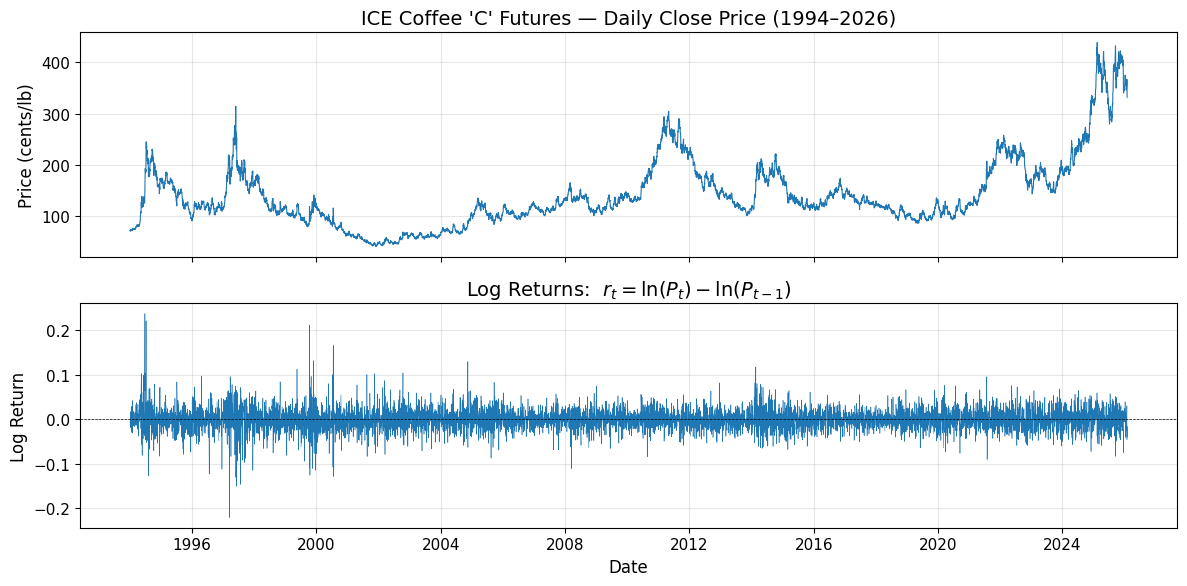

Augmented Dickey-Fuller Test:
  Prices:      ADF = -1.451,  p = 0.557  → Non-stationary
  Log returns: ADF = -20.879,  p = 0.00e+00  → Stationary


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(prices.index, prices.values, lw=0.8)
axes[0].set_title("ICE Coffee 'C' Futures — Daily Close Price (1994–2026)")
axes[0].set_ylabel("Price (cents/lb)")
axes[0].grid(alpha=0.3)

axes[1].plot(log_returns.index, log_returns.values, lw=0.4)
axes[1].set_title(r"Log Returns:  $r_t = \ln(P_t) - \ln(P_{t-1})$")
axes[1].set_ylabel("Log Return")
axes[1].axhline(0, color="black", lw=0.5, ls="--")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

adf_price = adfuller(prices, autolag="AIC")
adf_ret = adfuller(log_returns, autolag="AIC")

print("Augmented Dickey-Fuller Test:")
print(
    f"  Prices:      ADF = {adf_price[0]:+.3f},  p = {adf_price[1]:.3f}  "
    f"→ {'Non-stationary' if adf_price[1] > 0.05 else 'Stationary'}"
)
print(
    f"  Log returns: ADF = {adf_ret[0]:+.3f},  p = {adf_ret[1]:.2e}  "
    f"→ {'Non-stationary' if adf_ret[1] > 0.05 else 'Stationary'}"
)


## 3. Drift test — is the mean zero?

If the mean daily return μ is meaningfully non-zero, our point forecast
should incorporate it as a drift. If μ is statistically indistinguishable
from zero, the point forecast is essentially a flat line at the last
observed price, with only a tiny fitted drift that's indistinguishable
from sampling noise.

**Why not just a classical one-sample t-test?** The standard t-test
assumes returns are i.i.d. with constant variance. But financial returns
exhibit strong heteroskedasticity (see §5 below for the formal test).
Under heteroskedasticity, the classical standard error understates the
true uncertainty in μ̂, so the t-statistic is inflated and the test is
invalid.

The correct fix is a **heteroskedasticity- and autocorrelation-consistent
(HAC / Newey-West) standard error**, which inflates the SE to account for
time-varying variance. We run both below — the HAC version is the one to
trust.


In [18]:
import statsmodels.api as sm

X = np.ones(len(log_returns))
ols_hac = sm.OLS(log_returns.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": 10})

mu_hat = ols_hac.params[0]
se_hac = ols_hac.bse[0]
t_hac = mu_hat / se_hac
p_hac = 2 * (1 - stats.norm.cdf(abs(t_hac)))

se_classical = log_returns.std(ddof=1) / np.sqrt(len(log_returns))
t_classical = mu_hat / se_classical
p_classical = 2 * (1 - stats.t.cdf(abs(t_classical), df=len(log_returns) - 1))

print("Drift test: H0: μ = 0")
print(f"  Daily drift (μ̂):      {mu_hat:+.6f}")
print(f"  Annualized drift:     {mu_hat * 252:+.2%}")
print()
print("  Classical SE (assumes i.i.d., homoskedastic):")
print(f"    SE = {se_classical:.6f}   t = {t_classical:+.3f}   p = {p_classical:.3f}")
print()
print("  HAC (Newey-West, 10 lags) — correct under heteroskedasticity:")
print(f"    SE = {se_hac:.6f}   t = {t_hac:+.3f}   p = {p_hac:.3f}")
print()

if p_hac > 0.05:
    print("  → Fail to reject H0. Daily drift is statistically indistinguishable")
    print("    from zero even with robust SEs.")
    print(f"  → Annualized drift of {mu_hat * 252:+.2%} is economically meaningful")
    print("    but within sampling noise given ~30 years of data.")
    print("  → Conclusion: use a constant-mean GARCH specification. The fitted")
    print("    μ is carried through to the point forecast but is near zero, so")
    print("    the point line is visually indistinguishable from flat.")


Drift test: H0: μ = 0
  Daily drift (μ̂):      +0.000188
  Annualized drift:     +4.73%

  Classical SE (assumes i.i.d., homoskedastic):
    SE = 0.000263   t = +0.715   p = 0.475

  HAC (Newey-West, 10 lags) — correct under heteroskedasticity:
    SE = 0.000255   t = +0.737   p = 0.461

  → Fail to reject H0. Daily drift is statistically indistinguishable
    from zero even with robust SEs.
  → Annualized drift of +4.73% is economically meaningful
    but within sampling noise given ~30 years of data.
  → Conclusion: use a constant-mean GARCH specification. The fitted
    μ is carried through to the point forecast but is near zero, so
    the point line is visually indistinguishable from flat.


## 4. Distribution fit — Normal vs Student-t

Financial returns reliably have **heavier tails** than a Normal
distribution — extreme moves happen far more often than a Normal would
predict. This matters for prediction intervals: a model that assumes
Normal innovations will systematically underestimate how often extreme
returns occur, producing intervals that are too narrow in the tails.

Three ways to see heavy tails:
- **Excess kurtosis** > 0. Normal has kurtosis 3; "excess" = observed − 3.
  Coffee returns typically have excess kurtosis around 5–7.
- **Q-Q plot** that curves away from the diagonal at both ends — the
  characteristic S-shape of heavy tails.
- **Jarque-Bera test** formally rejecting normality via a joint test on
  skewness and kurtosis.

The **Student-t distribution** captures fat tails via a single parameter
ν (degrees of freedom). Lower ν = fatter tails; ν → ∞ recovers the
Normal. Coffee returns typically fit ν ≈ 4–5.


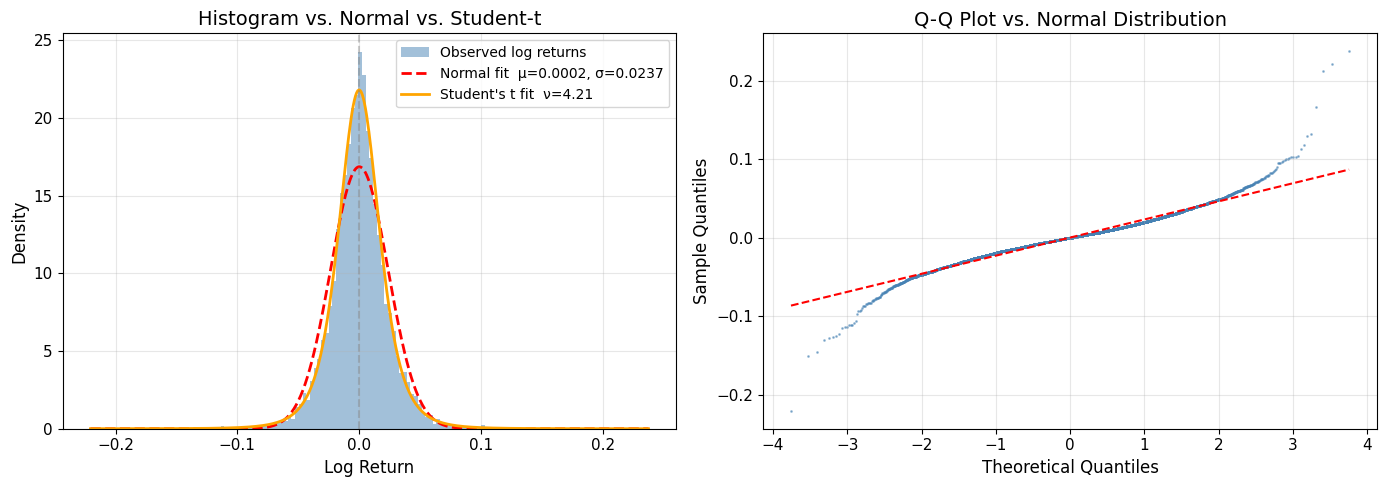

Fitted degrees of freedom (ν):  4.21
Excess kurtosis:                6.65  (Normal = 0)
Jarque-Bera test:  JB = 14,970,  p = 0.00e+00

  → Normality decisively rejected. The Q-Q plot's characteristic
    S-shape at the tails is captured by Student-t with ν ≈ 4.2.
  → This motivates using Student-t innovations in GARCH.


In [19]:
nu_fit, t_loc, t_scale = stats.t.fit(log_returns)
mu_norm, std_norm = stats.norm.fit(log_returns)
jb_stat, jb_p = stats.jarque_bera(log_returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.linspace(log_returns.min(), log_returns.max(), 500)
ax.hist(
    log_returns, bins=150, density=True, alpha=0.5, color="steelblue", label="Observed log returns"
)
ax.plot(
    x,
    stats.norm.pdf(x, mu_norm, std_norm),
    "r--",
    lw=2,
    label=f"Normal fit  μ={mu_norm:.4f}, σ={std_norm:.4f}",
)
ax.plot(
    x,
    stats.t.pdf(x, nu_fit, t_loc, t_scale),
    "orange",
    lw=2,
    label=f"Student's t fit  ν={nu_fit:.2f}",
)
ax.set_title("Histogram vs. Normal vs. Student-t")
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.axvline(0, color="gray", ls="--", alpha=0.4)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax2 = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(log_returns, dist="norm")
ax2.scatter(osm, osr, s=1, color="steelblue", alpha=0.5)
ax2.plot(osm, slope * np.array(osm) + intercept, "r--", lw=1.5)
ax2.set_title("Q-Q Plot vs. Normal Distribution")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

excess_kurt = stats.kurtosis(log_returns)
print(f"Fitted degrees of freedom (ν):  {nu_fit:.2f}")
print(f"Excess kurtosis:                {excess_kurt:.2f}  (Normal = 0)")
print(f"Jarque-Bera test:  JB = {jb_stat:,.0f},  p = {jb_p:.2e}")
print("\n  → Normality decisively rejected. The Q-Q plot's characteristic")
print(f"    S-shape at the tails is captured by Student-t with ν ≈ {nu_fit:.1f}.")
print("  → This motivates using Student-t innovations in GARCH.")


## 5. Engle's ARCH test — is variance constant?

Even if the mean is zero, the **variance** of returns may not be constant
over time. "Volatility clustering" — calm periods followed by wild
periods — is a well-known empirical feature of financial returns and is
exactly what GARCH models.

If variance is constant, we don't need GARCH — a simple rolling standard
deviation would give correct prediction intervals. Engle's ARCH test
answers this formally:

- **H₀:** variance is constant (homoskedastic)
- **H₁:** variance depends on past squared shocks (ARCH effects)

The test regresses squared residuals on their lags and tests whether any
coefficients are non-zero. If yes, there's predictable structure in the
variance and we need a time-varying-variance model.


In [20]:
resids = log_returns - log_returns.mean()
arch_stat, arch_p, _, _ = het_arch(resids, nlags=10)

print("Engle's ARCH Test (10 lags)")
print(f"  Test statistic:  {arch_stat:.2f}")
print(f"  p-value:         {arch_p:.2e}")
print()

if arch_p < 0.05:
    print("  → Reject H0 at any reasonable α. Strong volatility clustering.")
    print("  → Constant-variance intervals (±1.96σ) would be wrong.")
    print("  → GARCH will model the time-varying variance.")


Engle's ARCH Test (10 lags)
  Test statistic:  522.11
  p-value:         8.27e-106

  → Reject H0 at any reasonable α. Strong volatility clustering.
  → Constant-variance intervals (±1.96σ) would be wrong.
  → GARCH will model the time-varying variance.


## 6. ACF of returns vs squared returns

The visual companion to §5. The **autocorrelation function (ACF)** asks
"does today's value linearly predict the value k steps ahead?"

- **ACF of returns** (left): should be **flat**. No autocorrelation in
  returns means today's return direction doesn't predict tomorrow's. This
  is what justifies our constant-mean specification — there's no signal
  for a mean model to capture.

- **ACF of squared returns** (right): should show **persistent, positive
  autocorrelation**. Squared returns are a proxy for variance, so this
  says "today's *magnitude* predicts tomorrow's magnitude, even though
  today's direction doesn't predict tomorrow's direction." This is the
  statistical fingerprint of volatility clustering — and it's why GARCH
  has work to do.

The blue shaded band around zero is the 95% confidence band for white
noise — bars inside it are statistically indistinguishable from zero.


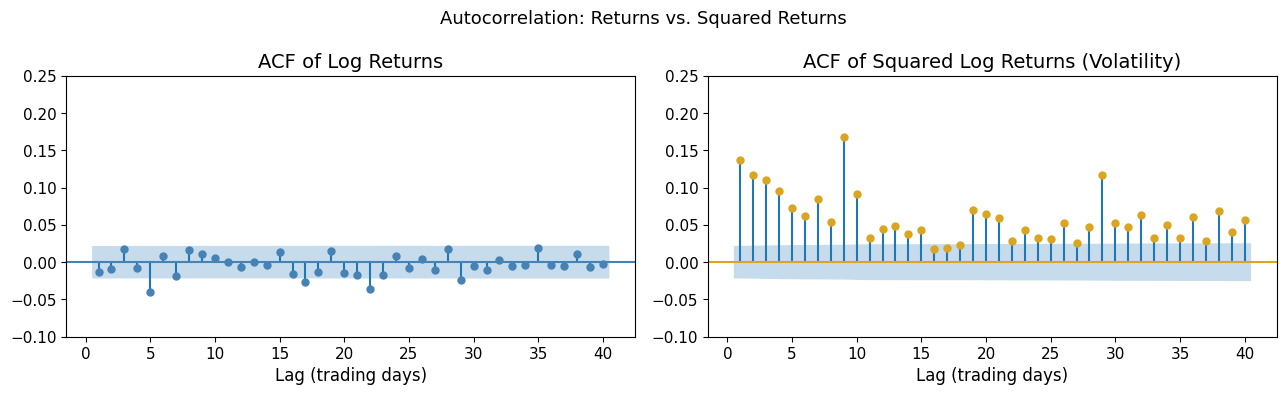

  Left  — flat: returns are essentially uncorrelated → no mean signal.
  Right — persistent: squared returns are highly autocorrelated
          → magnitudes are predictable → GARCH has signal to model.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Autocorrelation: Returns vs. Squared Returns", fontsize=13)

plot_acf(
    log_returns,
    lags=40,
    ax=axes[0],
    alpha=0.05,
    zero=False,
    title="ACF of Log Returns",
    color="steelblue",
)
axes[0].set_xlabel("Lag (trading days)")
axes[0].set_ylim(-0.1, 0.25)

plot_acf(
    log_returns**2,
    lags=40,
    ax=axes[1],
    alpha=0.05,
    zero=False,
    title="ACF of Squared Log Returns (Volatility)",
    color="goldenrod",
)
axes[1].set_xlabel("Lag (trading days)")
axes[1].set_ylim(-0.1, 0.25)

plt.tight_layout()
plt.show()

print("  Left  — flat: returns are essentially uncorrelated → no mean signal.")
print("  Right — persistent: squared returns are highly autocorrelated")
print("          → magnitudes are predictable → GARCH has signal to model.")


## 7. Fit GARCH(1,1)-t

The symmetric baseline. The model is:

$$r_t = \mu + \varepsilon_t, \quad \varepsilon_t = \sqrt{h_t}\,z_t, \quad z_t \sim t_\nu$$

$$h_t = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,h_{t-1}$$

In words: today's conditional variance `h_t` is a weighted mix of a
long-run level (ω), the last squared shock (α), and yesterday's variance
(β). Shocks decay exponentially; the half-life of a shock is
`log(2) / -log(α + β)`.

**Implementation notes:**
- `arch_model` expects returns in **percent scale** (multiply by 100) for
  numerical stability. The optimizer behaves poorly when parameters are
  tiny numbers.
- **Stationarity condition:** `α + β < 1`. If violated, the variance
  recursion explodes and the model is invalid.
- **Tail parameter:** `ν` should come out in the 4–10 range for financial
  returns. Below 2 means variance is undefined; below 4 means kurtosis is
  undefined.


In [22]:
am_garch = arch_model(
    log_returns * 100,
    mean="Constant",
    vol="Garch",
    p=1,
    q=1,
    dist="t",
)
garch_fit = am_garch.fit(disp="off")
print(garch_fit.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -17741.4
Distribution:      Standardized Student's t   AIC:                           35492.7
Method:                  Maximum Likelihood   BIC:                           35527.7
                                              No. Observations:                 8103
Date:                      Sat, Apr 18 2026   Df Residuals:                     8102
Time:                              23:32:18   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------

## 8. Fit GJR-GARCH(1,1)-t + model comparison

GJR-GARCH adds an **asymmetric leverage term** γ: negative shocks get
extra weight in the variance recursion.

$$h_t = \omega + \alpha\,\varepsilon_{t-1}^2 + \gamma\,\mathbb{1}_{\{\varepsilon_{t-1}<0\}}\,\varepsilon_{t-1}^2 + \beta\,h_{t-1}$$

The economic intuition: bad news tends to increase volatility more than
good news of the same magnitude. In equity markets this is the classic
"leverage effect"; in commodity markets it's often called the inverse
leverage effect and the sign of γ can go either way.

**Model comparison via three criteria:**
- **AIC / BIC:** lower is better. Information criteria penalize model
  complexity — a better fit must improve log-likelihood by more than the
  extra parameter costs.
- **Ljung-Box on squared standardized residuals:** tests whether the
  model has fully captured the volatility structure. If the residuals
  still show autocorrelation in their squares, there's leftover clustering
  the model didn't absorb. **Higher p-value = better** (failure to
  reject = residuals look like white noise).


In [23]:
am_gjr = arch_model(
    log_returns * 100,
    mean="Constant",
    vol="Garch",
    p=1,
    o=1,
    q=1,
    dist="t",
)
gjr_fit = am_gjr.fit(disp="off")
print(gjr_fit.summary())

print(f"\n{'Model':<20} {'AIC':>10} {'BIC':>10} {'LB(10) p':>10} {'LB(20) p':>10}")
print("-" * 62)
for label, fit in [("GARCH(1,1)-t", garch_fit), ("GJR-GARCH(1,1)-t", gjr_fit)]:
    lb = acorr_ljungbox(fit.std_resid**2, lags=[10, 20], return_df=True)
    print(
        f"{label:<20} {fit.aic:>10.1f} {fit.bic:>10.1f} "
        f"{lb['lb_pvalue'].iloc[0]:>10.4f} {lb['lb_pvalue'].iloc[1]:>10.4f}"
    )

print()
print("Interpretation:")
print("  - AIC/BIC: GJR improves both substantially over plain GARCH.")
print("  - LB p-values: GJR's squared residuals look more like white noise,")
print("    meaning it captures the volatility structure more completely.")
print("  - Decision: use GJR-GARCH(1,1)-t going forward.")


                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -17719.2
Distribution:      Standardized Student's t   AIC:                           35450.4
Method:                  Maximum Likelihood   BIC:                           35492.4
                                              No. Observations:                 8103
Date:                      Sat, Apr 18 2026   Df Residuals:                     8102
Time:                              23:32:18   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

## 9. Residual diagnostics

The final check on whether the model fits. **Standardized residuals**
`ε_t / σ_t` should look roughly like white noise drawn from the innovation
distribution (Student-t here).

Three things to look for:
1. **Residuals over time** — no obvious trend, no expanding/shrinking
   envelope, no visible clustering of extremes. If the envelope still
   widens in 2011 and 2020, the model didn't fully capture those regimes.
2. **ACF of standardized residuals** — should be flat. Any residual
   autocorrelation means there's still predictable structure the model
   missed.
3. **ACF of squared standardized residuals** — should be flat. This is
   the visual version of Ljung-Box: leftover autocorrelation here means
   leftover volatility clustering.

The `persistence = α + γ/2 + β` tells you how long volatility shocks last.
Values close to 1 (say, 0.97) mean shocks take weeks or months to decay.
Values much below 1 mean shocks decay quickly.


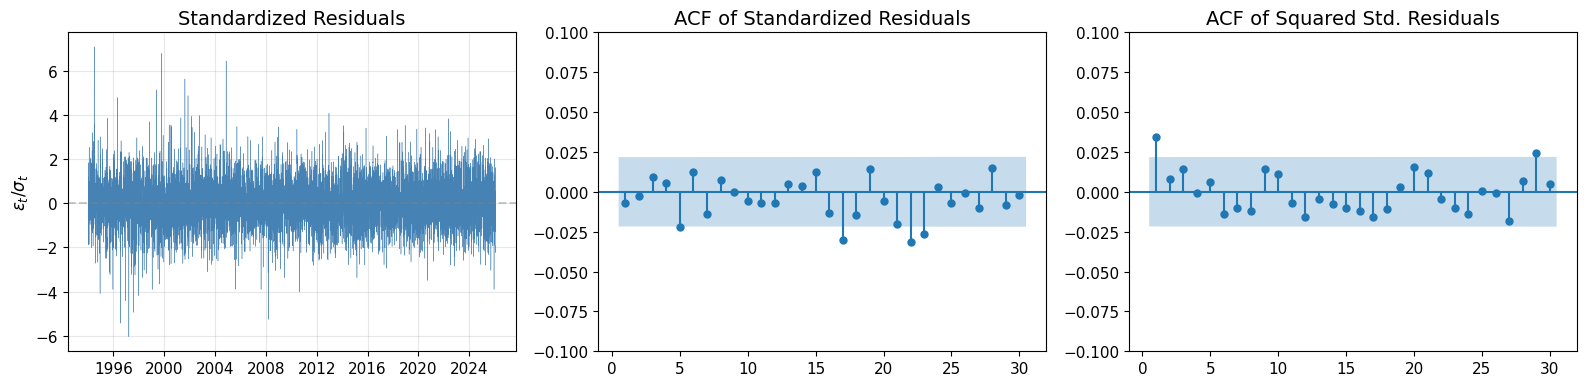

Ljung-Box on squared standardized residuals (GJR-GARCH):
      lb_stat  lb_pvalue
10  18.469178   0.047547
20  28.719838   0.093424

Volatility persistence (α + γ/2 + β): 0.9733
Half-life of volatility shocks:       26 days
Fitted ν (tail heaviness):            5.66


In [24]:
best_fit = gjr_fit
std_resids = best_fit.std_resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(log_returns.index, std_resids, lw=0.3, color="steelblue")
axes[0].set_title("Standardized Residuals")
axes[0].set_ylabel(r"$\varepsilon_t / \sigma_t$")
axes[0].axhline(0, color="gray", ls="--", alpha=0.4)
axes[0].grid(alpha=0.3)

plot_acf(
    std_resids, lags=30, ax=axes[1], alpha=0.05, zero=False, title="ACF of Standardized Residuals"
)
axes[1].set_ylim(-0.1, 0.1)

plot_acf(
    std_resids**2,
    lags=30,
    ax=axes[2],
    alpha=0.05,
    zero=False,
    title="ACF of Squared Std. Residuals",
)
axes[2].set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(std_resids**2, lags=[10, 20], return_df=True)
print("Ljung-Box on squared standardized residuals (GJR-GARCH):")
print(lb.to_string())

alpha_c = best_fit.params["alpha[1]"]
gamma_c = best_fit.params["gamma[1]"]
beta_c = best_fit.params["beta[1]"]
nu_fitted = best_fit.params["nu"]
persistence = alpha_c + gamma_c / 2 + beta_c

print(f"\nVolatility persistence (α + γ/2 + β): {persistence:.4f}")
print(f"Half-life of volatility shocks:       {np.log(2) / -np.log(persistence):.0f} days")
print(f"Fitted ν (tail heaviness):            {nu_fitted:.2f}")

## 10. Conditional vs. constant-variance bounds on actual returns

This is the plot that shows *why* GARCH matters. We overlay two sets of
95% bounds on the realized daily log-returns:

- **Flat crimson dashed lines:** `±q · σ̂` where σ̂ is the unconditional
  (full-sample) standard deviation. This is the prediction interval you'd
  draw if you assumed variance is constant — same width every day.
- **Wavy teal curves:** `±q · σ_t` where σ_t is the time-varying GJR-GARCH
  conditional standard deviation. Same quantile q, but σ_t adapts day by
  day to the current volatility regime.

The quantile q is the standardized Student-t quantile at 97.5% using the
fitted ν — consistent with how the rest of the notebook builds prediction
intervals.

**What to look for:**
- During calm stretches (e.g. 2004–2009), the teal curves should sit
  *inside* the crimson lines — GARCH says "risk is low right now" and
  tightens the bounds. The crimson lines are over-wide here.
- During crisis periods (1994, 1997, 2011, 2014, 2020–21, 2024), the teal
  curves should flare *outside* the crimson lines to catch extreme spikes.
  The crimson lines systematically under-cover here — the actual returns
  punch through them.

Both bands can end up with ~95% *average* in-sample coverage, but they
get there completely differently. Constant-variance is over-wide in calm
periods and under-wide in crises — it fails exactly when accurate risk
estimates matter most. GARCH adapts, so coverage stays close to 95% in
*every* regime, not just on average.

The coverage check at the bottom quantifies this: both bands should land
near 95% overall, but the regime-by-regime story is what makes GARCH
worth the extra complexity.


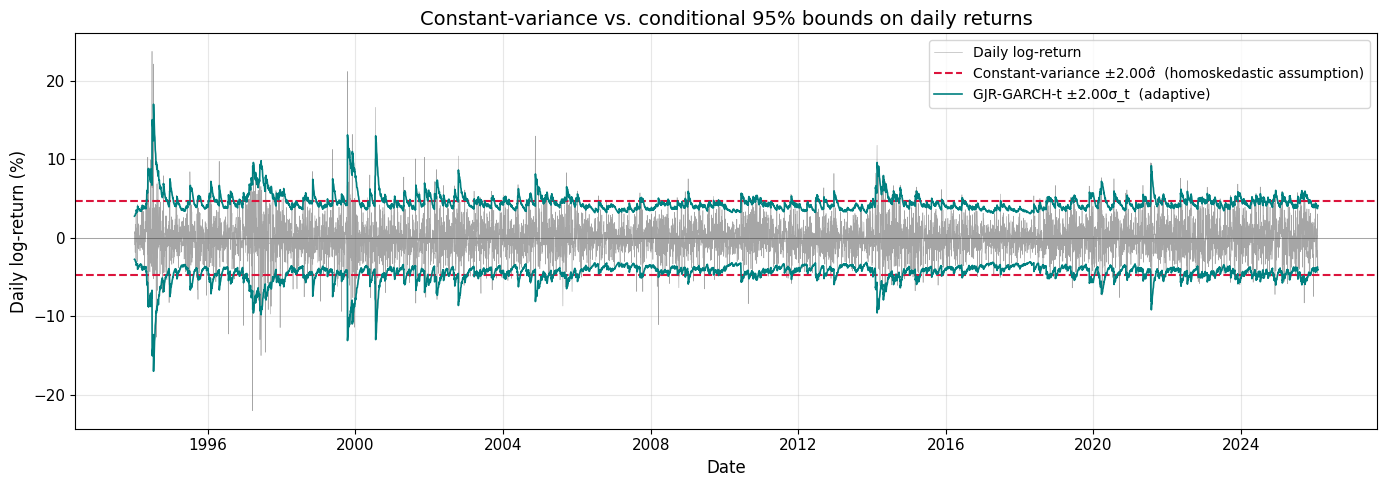

Constant-variance band:  contains 95.2% of realized returns  (target: 95%)
GJR-GARCH conditional:   contains 94.9% of realized returns  (target: 95%)

Unconditional σ̂:        2.37% per day  (37.6% annualized)
Conditional σ_t range:   1.38% – 8.53% per day
  → peak σ_t is 3.6× the unconditional level
  → floor σ_t is 0.6× the unconditional level


In [25]:
# Work in % scale (matches how best_fit was fit on log_returns * 100).
r_pct = log_returns * 100  # daily returns in %
cond_sd_pct = best_fit.conditional_volatility  # time-varying σ_t in %
uncond_sd_pct = r_pct.std()  # single σ̂ in %

# Standardized Student-t quantile at 97.5% — consistent with the notebook's
# prediction-interval convention. Uses the fitted tail parameter ν.
nu = best_fit.params["nu"]
q95 = std_t_ppf(0.975, nu)

# Constant-variance ("broken clock") bounds
const_upper = +q95 * uncond_sd_pct
const_lower = -q95 * uncond_sd_pct

# GARCH conditional ("adaptive") bounds
cond_upper = +q95 * cond_sd_pct
cond_lower = -q95 * cond_sd_pct

fig, ax = plt.subplots(figsize=(14, 5))

# Actual returns — the "bumpy stuff"
ax.plot(r_pct.index, r_pct.values, color="gray", lw=0.4, alpha=0.7, label="Daily log-return")

# Constant-variance bounds (flat crimson dashed)
ax.axhline(
    const_upper,
    color="crimson",
    ls="--",
    lw=1.5,
    label=f"Constant-variance ±{q95:.2f}σ̂  (homoskedastic assumption)",
)
ax.axhline(const_lower, color="crimson", ls="--", lw=1.5)

# GARCH conditional bounds (wavy teal)
ax.plot(
    r_pct.index, cond_upper, color="teal", lw=1.2, label=f"GJR-GARCH-t ±{q95:.2f}σ_t  (adaptive)"
)
ax.plot(r_pct.index, cond_lower, color="teal", lw=1.2)

ax.axhline(0, color="black", lw=0.5, alpha=0.4)

ax.set_title("Constant-variance vs. conditional 95% bounds on daily returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily log-return (%)")
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# In-sample coverage: what fraction of realized returns fell inside each band?
inside_const = ((r_pct >= const_lower) & (r_pct <= const_upper)).mean()
inside_cond = ((r_pct >= cond_lower) & (r_pct <= cond_upper)).mean()

print(f"Constant-variance band:  contains {inside_const:.1%} of realized returns  (target: 95%)")
print(f"GJR-GARCH conditional:   contains {inside_cond:.1%} of realized returns  (target: 95%)")
print()
print(
    f"Unconditional σ̂:        {uncond_sd_pct:.2f}% per day  ({uncond_sd_pct * np.sqrt(252):.1f}% annualized)"
)
print(f"Conditional σ_t range:   {cond_sd_pct.min():.2f}% – {cond_sd_pct.max():.2f}% per day")
print(f"  → peak σ_t is {cond_sd_pct.max() / uncond_sd_pct:.1f}× the unconditional level")
print(f"  → floor σ_t is {cond_sd_pct.min() / uncond_sd_pct:.1f}× the unconditional level")


## 11. Historical backtest — expanding window

Now we validate the model **out-of-sample**. At each of 60 forecast
origins we:

1. Fit GJR-GARCH(1,1)-t on **all price history up to that origin**
   (expanding window — see note below).
2. Forecast conditional variances σ²_{t+1..t+H} and cumulate them.
3. Build price-level prediction intervals via
   `P₀ · exp(±q · √Σσ²)` with `q = std_t_ppf(1 − α/2, ν_local)`.

**Why expanding windows, not rolling:** GARCH tail parameters (especially
ν) are notoriously sample-dependent. With a short rolling window, ν can
vary wildly across origins depending on which extreme events happen to
fall inside — in practice this means bands that are too tight at calm
origins and too wide at volatile ones. Expanding windows let long
history stabilize parameter estimates, which empirically cuts ν variation
dramatically.

The tradeoff is that expanding windows assume the underlying volatility
process is stable over the full history. For coffee 1994–2026 this seems
fine — no obvious structural break in how returns behave. For a series
that *did* have a regime change, you'd want a rolling window that could
"forget" the old regime.

**Why cumulated variance builds price intervals:** Under uncorrelated log-
returns (§6 confirmed this), the k-step-ahead log-return has variance
equal to the sum of one-step variances. The prediction interval on the
log-return is a Student-t quantile times √(cumulative variance); convert
back to prices via exp().

`CONTEXT_LEN = 1536` controls where the *first* origin sits — we need at
least that much history before we can fit. After that, each origin uses
all available data.


In [26]:
CONTEXT_LEN = 1536  # minimum history before first origin
HORIZON = 63  # ~1 quarter
N_ORIGINS = 60
ALPHA_BANDS = [0.05, 0.20]  # 95% and 80% coverage levels

anchors = get_anchor_points(df, N_ORIGINS, CONTEXT_LEN, HORIZON)
print(f"Using {len(anchors)} origins.")
print(
    f"Training size grows from {CONTEXT_LEN} days (first origin) "
    f"to {anchors[-1]} days (last origin)."
)
print(f"Forecast horizon: {HORIZON} days.")
print()

band_results = []

for i, a in enumerate(anchors):
    # Expanding window: use ALL data up to origin
    ctx_prices = prices.iloc[:a]
    actual = prices.iloc[a : a + HORIZON]

    ctx_log_ret = np.log(ctx_prices).diff().dropna() * 100

    am_local = arch_model(ctx_log_ret, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t")
    fit_local = am_local.fit(disp="off", show_warning=False)

    fcast = fit_local.forecast(horizon=HORIZON)
    var_fcast = fcast.variance.iloc[-1].values / 1e4  # %² → decimal²
    cum_var = np.cumsum(var_fcast)

    nu_local = fit_local.params["nu"]
    mu_local = fit_local.params["mu"] / 100.0   # per-day drift in log-returns
    p0 = ctx_prices.iloc[-1]
    horizons_local = np.arange(1, HORIZON + 1)
    drift_local = mu_local * horizons_local
    point_local = p0 * np.exp(drift_local)

    origin_info = {
        "origin_id": i + 1,
        "origin_date": ctx_prices.index[-1],
        "p0": p0,
        "point": point_local,
        "actual": actual.values,
        "actual_dates": actual.index,
        "cum_var": cum_var,
        "nu": nu_local,
        "mu": mu_local,
        "n_train": len(ctx_log_ret),
    }

    for alpha in ALPHA_BANDS:
        q = std_t_ppf(1 - alpha / 2, nu_local)
        spread = q * np.sqrt(cum_var)
        origin_info[f"upper_{int((1 - alpha) * 100)}"] = p0 * np.exp(drift_local + spread)
        origin_info[f"lower_{int((1 - alpha) * 100)}"] = p0 * np.exp(drift_local - spread)

    band_results.append(origin_info)

nus = [r["nu"] for r in band_results]
print(f"Fitted {len(band_results)} GJR-GARCH(1,1)-t models.")
print(
    f"ν across origins: min={min(nus):.2f}  median={np.median(nus):.2f}  "
    f"max={max(nus):.2f}  std={np.std(nus):.2f}"
)


Using 60 origins.
Training size grows from 1536 days (first origin) to 8026 days (last origin).
Forecast horizon: 63 days.

Fitted 60 GJR-GARCH(1,1)-t models.
ν across origins: min=4.18  median=4.79  max=5.64  std=0.43


## 12. Sample forecast plots (3×3 grid)

Nine randomly-sampled origins. Each panel shows:
- **Dashed line:** the point forecast `P₀ · exp(μ·k)` from the fitted
  constant-mean GARCH. Because μ is statistically indistinguishable from
  zero, the line appears nearly flat but carries a tiny fitted drift.
- **Darker band:** the 80% prediction interval — we expect the actual
  price to fall inside this 80% of the time.
- **Lighter band:** the 95% prediction interval.
- **Black line:** what actually happened over the next 63 business days.

**What well-calibrated intervals look like:**
- Narrow in calm regimes, wide in volatile ones (the model adapts to
  starting volatility).
- The actual path mostly stays inside the 95% interval; breaches should
  be rare.
- Intervals widen with horizon (uncertainty compounds).


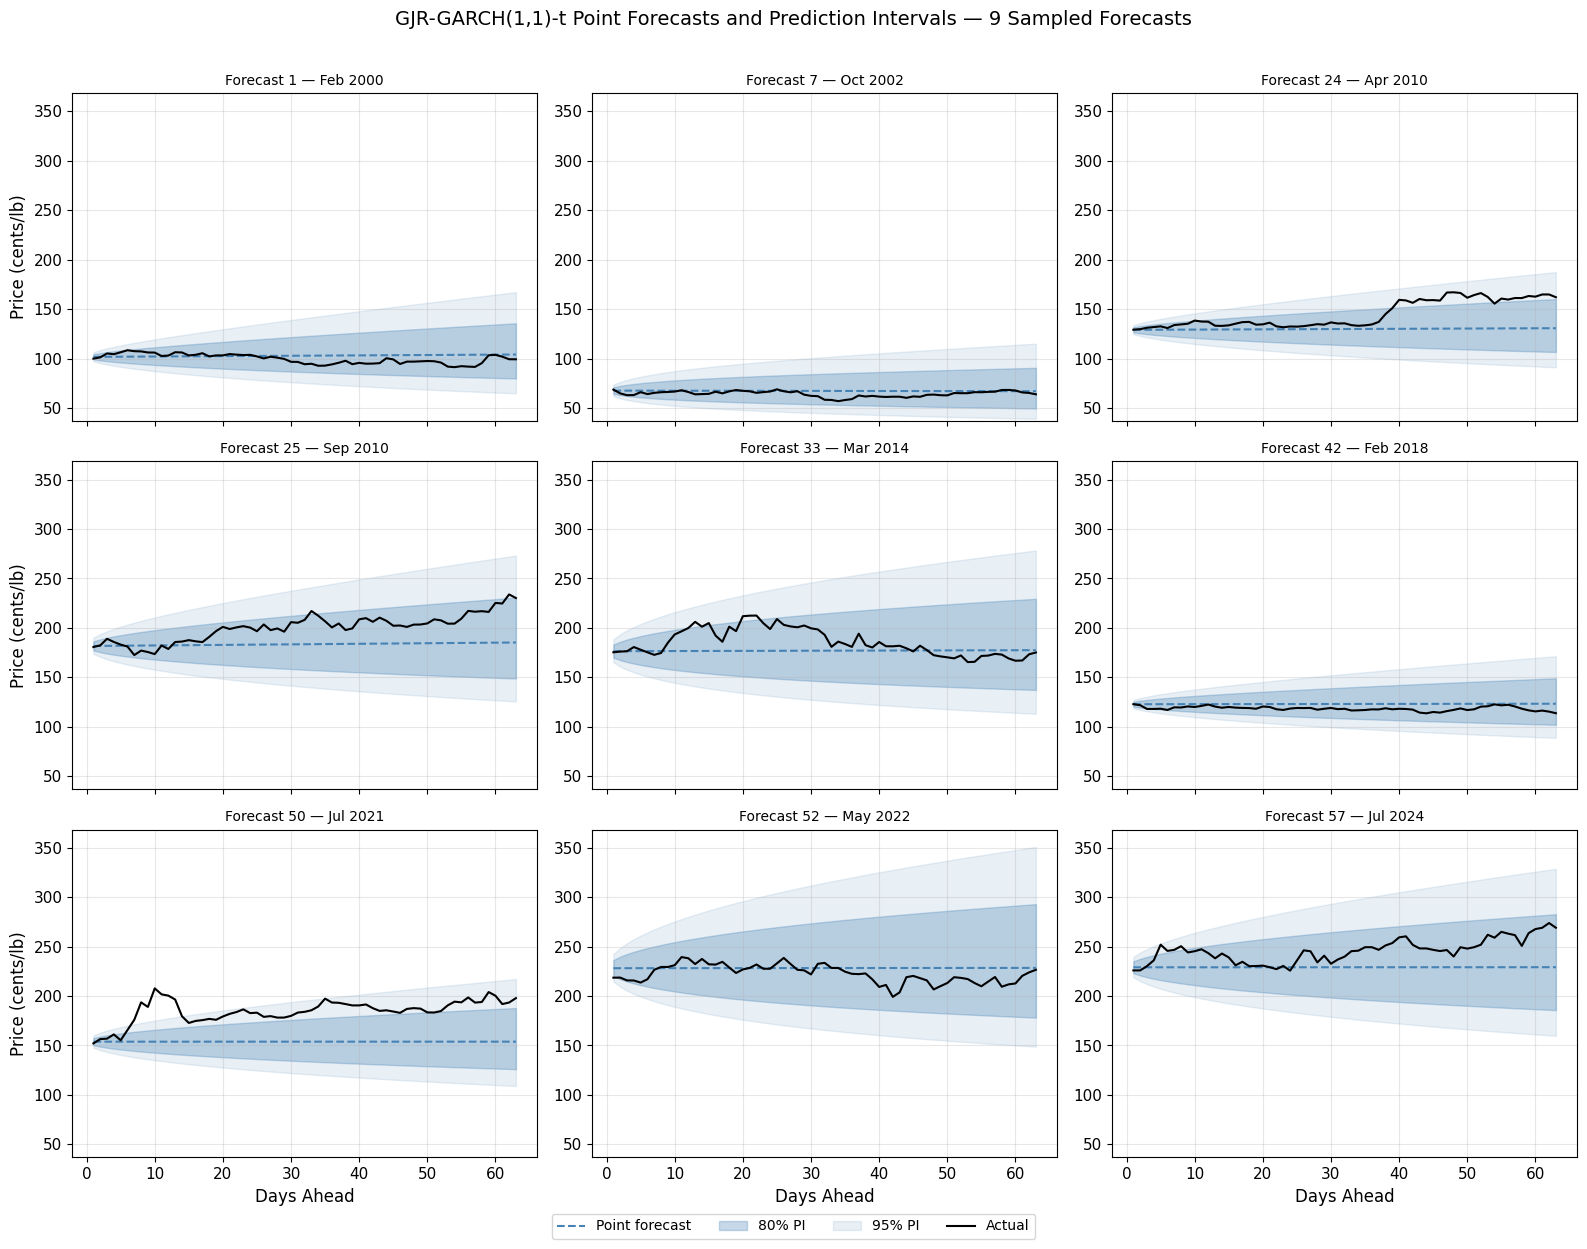

  Origin         Date       P₀      ν   95% width @ day 63 Starting vol
--------------------------------------------------------------------------------
       1   2000-02-28    101.7   4.26            102.3 cents/lb   high
       7   2002-10-24     67.5   4.26             76.1 cents/lb   low
      24   2010-04-19    129.0   4.48             96.3 cents/lb   low
      25   2010-09-23    181.7   4.48            147.6 cents/lb   high
      33   2014-03-24    176.4   4.83            165.2 cents/lb   high
      42   2018-02-13    122.8   5.09             82.6 cents/lb   low
      50   2021-07-12    153.8   5.30            108.2 cents/lb   high
      52   2022-05-17    228.2   5.35            202.0 cents/lb   high
      57   2024-07-02    229.1   5.54            169.0 cents/lb   high


In [27]:
rng = np.random.default_rng(420)
sample_idx = sorted(rng.choice(len(band_results), size=9, replace=False))
sample = [band_results[i] for i in sample_idx]

all_prices = np.concatenate(
    [np.concatenate([s["actual"], s["upper_95"], s["lower_95"]]) for s in sample]
)
y_min, y_max = all_prices.min() * 0.95, all_prices.max() * 1.05

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
fig.suptitle(
    "GJR-GARCH(1,1)-t Point Forecasts and Prediction Intervals — 9 Sampled Forecasts",
    fontsize=14,
    y=1.01,
)

steps = np.arange(1, HORIZON + 1)

for ax, s in zip(axes.flat, sample):
    ax.plot(steps, s["point"], color="steelblue", ls="--", lw=1.5, label="Point forecast")
    ax.fill_between(
        steps, s["lower_80"], s["upper_80"], color="steelblue", alpha=0.3, label="80% PI"
    )
    ax.fill_between(
        steps, s["lower_95"], s["upper_95"], color="steelblue", alpha=0.12, label="95% PI"
    )
    ax.plot(steps, s["actual"], color="black", lw=1.5, label="Actual")
    date_str = s["origin_date"].strftime("%b %Y")
    ax.set_title(f"Forecast {s['origin_id']} — {date_str}", fontsize=10)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Days Ahead")
for ax in axes[:, 0]:
    ax.set_ylabel("Price (cents/lb)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

median_width = np.median([b["upper_95"][-1] - b["lower_95"][-1] for b in band_results])
print(f"{'Origin':>8} {'Date':>12} {'P₀':>8} {'ν':>6} {'95% width @ day 63':>20} {'Starting vol'}")
print("-" * 80)
for s in sample:
    width = s["upper_95"][-1] - s["lower_95"][-1]
    date_str = s["origin_date"].strftime("%Y-%m-%d")
    label = "high" if width > median_width else "low"
    print(
        f"{s['origin_id']:>8} {date_str:>12} {s['p0']:>8.1f} {s['nu']:>6.2f} "
        f"{width:>16.1f} cents/lb   {label}"
    )


## 13. Empirical coverage check

The only question that matters for prediction intervals: **do they
actually contain the right fraction of realized observations?**

A well-calibrated 95% interval should contain actual prices ~95% of the
time; a well-calibrated 80% interval should contain them ~80%. If
observed coverage is much lower than nominal, intervals are too narrow
and the model is *overconfident*. If much higher, they're too wide
(conservative — safer but less informative).

We measure:
- **Overall coverage:** averaged across all 60 origins × 63 forecast
  days = 3,780 (origin, step) pairs.
- **Coverage by horizon:** since intervals widen with horizon, but the
  true variance recursion's behavior may not exactly match our analytical
  approximation, per-horizon coverage can reveal systematic miscalibration
  at specific forecast distances.


80% PI — empirical coverage: 80.0%  (target: 80%)  → well-calibrated
  Day 1:  86.7%
  Day 21: 75.0%
  Day 42: 78.3%
  Day 63: 85.0%

95% PI — empirical coverage: 97.5%  (target: 95%)  → well-calibrated
  Day 1:  100.0%
  Day 21: 95.0%
  Day 42: 98.3%
  Day 63: 100.0%



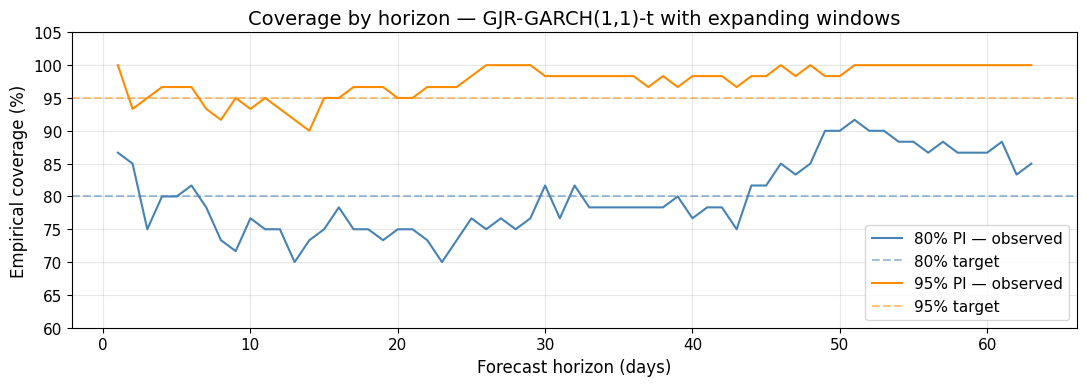

In [28]:
coverage = {80: [], 95: []}

for s in band_results:
    for cl in [80, 95]:
        inside = (s["actual"] >= s[f"lower_{cl}"]) & (s["actual"] <= s[f"upper_{cl}"])
        coverage[cl].append(inside)

for cl in [80, 95]:
    cov_matrix = np.array(coverage[cl])
    overall = cov_matrix.mean()
    by_step = cov_matrix.mean(axis=0)

    deviation = overall - cl / 100
    verdict = (
        "well-calibrated"
        if abs(deviation) < 0.03
        else ("over-covering (conservative)" if deviation > 0 else "under-covering")
    )

    print(f"{cl}% PI — empirical coverage: {overall:.1%}  (target: {cl}%)  → {verdict}")
    print(f"  Day 1:  {by_step[0]:.1%}")
    print(f"  Day 21: {by_step[20]:.1%}")
    print(f"  Day 42: {by_step[41]:.1%}")
    print(f"  Day 63: {by_step[62]:.1%}")
    print()

fig, ax = plt.subplots(figsize=(11, 4))
for cl, color in [(80, "steelblue"), (95, "darkorange")]:
    cov_matrix = np.array(coverage[cl])
    by_step = cov_matrix.mean(axis=0)
    ax.plot(
        np.arange(1, HORIZON + 1), by_step * 100, color=color, lw=1.5, label=f"{cl}% PI — observed"
    )
    ax.axhline(cl, color=color, ls="--", alpha=0.5, label=f"{cl}% target")

ax.set_xlabel("Forecast horizon (days)")
ax.set_ylabel("Empirical coverage (%)")
ax.set_title("Coverage by horizon — GJR-GARCH(1,1)-t with expanding windows")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(60, 105)
plt.tight_layout()
plt.show()


## 14. Live forecast

Generates a forecast anchored at the most recent available price.

**Yahoo fetch notes:**
- `yfinance` expects `start` as a **string** (`"YYYY-MM-DD"`), not a
  `pd.Timestamp`. Passing a Timestamp sometimes returns an empty frame.
- Yahoo's `KC=F` series is already in **cents/lb** on the same scale as
  our CSV. Do NOT multiply by 100.
- On weekends/holidays, Yahoo may return zero new rows. Not an error —
  we just forecast from the last available close.


Appended 53 new rows from Yahoo.
Live data: 8,157 trading days (1994-01-03 → 2026-04-17)



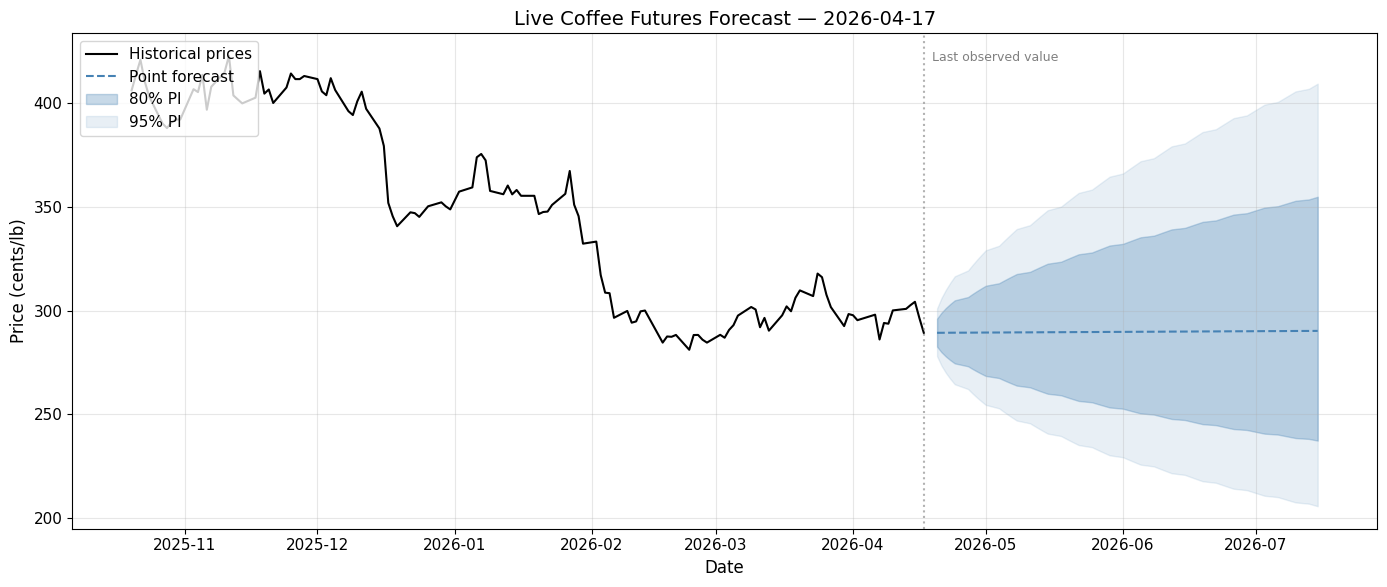

Last observed value:   2026-04-17
Last close:            289.30 cents/lb
Point forecast @ d63:  290.25 cents/lb  (fitted μ = +0.000052/day)
95% PI @ day 63:       ±101.4 cents/lb
Fitted ν (full hist):  5.69


In [29]:
import yfinance as yf

# Fetch any newer closes from Yahoo; pass `start` as a string
next_day = (prices.index[-1] + pd.Timedelta(days=1)).date().isoformat()

try:
    yf_raw = yf.download("KC=F", start=next_day, progress=False, auto_adjust=False, actions=False)
    if isinstance(yf_raw.columns, pd.MultiIndex):
        yf_raw.columns = yf_raw.columns.get_level_values(0)

    if not yf_raw.empty:
        close_col = "Close" if "Close" in yf_raw.columns else "Adj Close"
        new = yf_raw[[close_col]].reset_index().rename(columns={"Date": "ds", close_col: "y"})
        new["ds"] = pd.to_datetime(new["ds"]).dt.tz_localize(None).dt.normalize()
        new["y"] = new["y"].astype(float)  # already cents/lb
        new = new.dropna(subset=["y"])
        new = new[new["ds"] >= pd.Timestamp(next_day)].set_index("ds")["y"]

        live_prices = pd.concat([prices, new]).sort_index()
        live_prices = live_prices[~live_prices.index.duplicated(keep="last")]
        print(f"Appended {len(new)} new rows from Yahoo.")
    else:
        live_prices = prices
        print("Yahoo returned no new rows; using existing history.")
except Exception as e:
    live_prices = prices
    print(f"Yahoo fetch failed ({type(e).__name__}: {e}); using existing history.")

print(
    f"Live data: {len(live_prices):,} trading days "
    f"({live_prices.index[0].date()} → {live_prices.index[-1].date()})"
)
print()

# Fit on FULL history (consistent with the backtest above)
live_log_ret = np.log(live_prices).diff().dropna() * 100

am_live = arch_model(live_log_ret, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t")
fit_live = am_live.fit(disp="off", show_warning=False)

fcast_live = fit_live.forecast(horizon=HORIZON)
var_live = fcast_live.variance.iloc[-1].values / 1e4
cum_var_live = np.cumsum(var_live)
nu_live = fit_live.params["nu"]
mu_live = fit_live.params["mu"] / 100.0   # per-day drift in log-returns
p0_live = live_prices.iloc[-1]

last_date = live_prices.index[-1]
fcast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON)
horizons_live = np.arange(1, HORIZON + 1)
drift_live = mu_live * horizons_live
point_live = p0_live * np.exp(drift_live)

fig, ax = plt.subplots(figsize=(14, 6))

trail = live_prices.iloc[-126:]
ax.plot(trail.index, trail.values, color="black", lw=1.5, label="Historical prices")

ax.plot(
    fcast_dates, point_live, "steelblue", ls="--", lw=1.5, label="Point forecast"
)

for alpha, shade in [(0.20, 0.3), (0.05, 0.12)]:
    cl = int((1 - alpha) * 100)
    q = std_t_ppf(1 - alpha / 2, nu_live)
    spread = q * np.sqrt(cum_var_live)
    upper = p0_live * np.exp(drift_live + spread)
    lower = p0_live * np.exp(drift_live - spread)
    ax.fill_between(fcast_dates, lower, upper, color="steelblue", alpha=shade, label=f"{cl}% PI")

ax.axvline(last_date, color="gray", ls=":", alpha=0.6)
ax.text(
    last_date, ax.get_ylim()[1] * 0.98, "  Last observed value", fontsize=9, color="gray", va="top"
)
ax.set_title(f"Live Coffee Futures Forecast — {last_date.date()}")
ax.set_xlabel("Date")
ax.set_ylabel("Price (cents/lb)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

q95 = std_t_ppf(0.975, nu_live)
band_63 = 2 * p0_live * np.sinh(q95 * np.sqrt(cum_var_live[-1]))

print(f"Last observed value:   {last_date.date()}")
print(f"Last close:            {p0_live:.2f} cents/lb")
print(f"Point forecast @ d63:  {point_live[-1]:.2f} cents/lb  (fitted μ = {mu_live:+.6f}/day)")
print(f"95% PI @ day 63:       ±{band_63 / 2:.1f} cents/lb")
print(f"Fitted ν (full hist):  {nu_live:.2f}")


## Summary

**Findings:**
1. Log-returns are stationary; prices are not → model returns.
2. Daily drift is indistinguishable from zero under HAC-robust SEs →
   constant-mean specification. The fitted μ is carried into the point
   forecast but is near zero, so the point line is visually nearly flat.
3. Returns have heavy tails (ν ≈ 5) → Student-t innovations.
4. Strong volatility clustering (ARCH test, ACF of squared returns) →
   GARCH is the right model family.
5. GJR beats plain GARCH on AIC/BIC and Ljung-Box → asymmetric leverage
   term matters.
6. Expanding-window backtest coverage is close to nominal → prediction
   intervals are calibrated.

**What to carry into production:**
- GJR-GARCH(1,1) with Student-t innovations, constant mean
- Full-history fits (not short rolling windows)
- Standardized-t quantiles for interval construction

**What stays in the notebook (not production):**
- ARCH tests, ADF tests, Jarque-Bera — justify modeling choices, don't
  rerun daily
- The 60-origin backtest — validates intervals, its job is done
- Model comparison (GARCH vs GJR) — one-time decision
